# Step 3d: Classification Benchmark — RF vs XGBoost vs LightGBM

**Goal:** Benchmark tree-based classifiers predicting penicillin concentration classes (Low/Medium/High) using patch-based features from early window.

**Approach:**
- Segment early window into N equal patches
- Extract per-patch statistics: mean, std, min, max, slope
- **Stratified random split** to ensure balanced class representation in train/val/test
- Train RF, XGBoost, and LightGBM classifiers with GridSearchCV for hyperparameter tuning
- Compare models on accuracy, F1-macro, and log-loss

**Contents:**
1. Imports & Configuration
2. Load Data & Stratified Splits
3. Class Distribution Analysis
4. Patch Visualization
5. Feature Extraction Functions
6. Prepare Classification Data
7. RF Hyperparameter Tuning & Evaluation
8. XGBoost Classifier
9. LightGBM Classifier
10. Benchmark Comparison

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.data_loader import load_batches
from src.feature_config import INPUT_FEATURES_EXPANDED, SIGNAL_SPARSE_OFFLINE, get_signal_type
from src.preprocessing import extract_early_window, interpolate_sparse_feature

sns.set_theme(style='whitegrid')
%matplotlib inline

# Configuration
WINDOW_FRACTION = 0.9        # First fraction of batch seen
TARGET_TIME_FRACTION = 1.0   # 1.0 = end of batch (configurable)
N_PATCHES = 8               # Segment window into 4 patches
CLASS_THRESHOLDS = [15, 25]  # g/L boundaries
CLASS_NAMES = ["Low", "Medium", "High"]
RANDOM_STATE = 213

# Split ratios (stratified random split)
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

print(f"Configuration:")
print(f"  Window fraction: {WINDOW_FRACTION}")
print(f"  Number of patches: {N_PATCHES}")
print(f"  Class thresholds: {CLASS_THRESHOLDS} g/L")
print(f"  Target time fraction: {TARGET_TIME_FRACTION}")
print(f"  Input features: {len(INPUT_FEATURES_EXPANDED)}")
print(f"  Split ratios: Train={TRAIN_RATIO}, Val={VAL_RATIO}, Test={TEST_RATIO}")

Configuration:
  Window fraction: 0.9
  Number of patches: 8
  Class thresholds: [15, 25] g/L
  Target time fraction: 1.0
  Input features: 25
  Split ratios: Train=0.6, Val=0.2, Test=0.2


## 2. Load Data & Stratified Splits

Using stratified random sampling to ensure each split (train/val/test) has proportional representation of all classes.

In [2]:
# Load batches
batches = load_batches()
print(f"Loaded {len(batches)} batches")

# Exclude fault batches (91-100)
all_ids = list(range(1, 91))
print(f"Using {len(all_ids)} non-fault batches for stratified splitting")

# Helper functions for class assignment (defined early for splitting)
def get_target_p(df: pd.DataFrame, time_fraction: float = 1.0) -> float:
    """Get penicillin concentration at specified time fraction."""
    if time_fraction >= 1.0:
        return df["P"].iloc[-1]
    max_time = df["time"].max()
    target_time = max_time * time_fraction
    idx = (df["time"] - target_time).abs().idxmin()
    return df.loc[idx, "P"]

def assign_class(y: float, thresholds: list = CLASS_THRESHOLDS) -> int:
    """Assign class label based on thresholds."""
    if y < thresholds[0]:
        return 0
    elif y < thresholds[1]:
        return 1
    else:
        return 2

# Compute class labels for all batches
all_labels = [assign_class(get_target_p(batches[bid], TARGET_TIME_FRACTION)) for bid in all_ids]

# Stratified split: first split into train+val vs test
train_val_ids, test_ids, train_val_labels, test_labels = train_test_split(
    all_ids, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=RANDOM_STATE,
)

# Second split: train vs val (from train+val)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_ids, val_ids, train_labels, val_labels = train_test_split(
    train_val_ids, train_val_labels,
    test_size=val_ratio_adjusted,
    stratify=train_val_labels,
    random_state=RANDOM_STATE,
)

print(f"\nStratified Split (random, class-balanced):")
print(f"  Train: {len(train_ids)} batches")
print(f"  Val: {len(val_ids)} batches")
print(f"  Test: {len(test_ids)} batches")

Loaded 100 batches
Using 90 non-fault batches for stratified splitting

Stratified Split (random, class-balanced):
  Train: 54 batches
  Val: 18 batches
  Test: 18 batches


## 3. Class Distribution Analysis

In [3]:
# Get P values and class labels for all batches (already computed, but create DataFrame)
p_values = {bid: get_target_p(batches[bid], TARGET_TIME_FRACTION) for bid in all_ids}
class_labels = {bid: assign_class(p_values[bid]) for bid in all_ids}

# Create DataFrame for visualization
p_df = pd.DataFrame([
    {"batch_id": bid, "P": p_values[bid], "class": class_labels[bid]}
    for bid in all_ids
])

print(f"Class distribution (all {len(all_ids)} non-fault batches):")
for c, name in enumerate(CLASS_NAMES):
    count = (p_df["class"] == c).sum()
    print(f"  {name}: {count} batches ({count/len(all_ids)*100:.1f}%)")

print(f"\nP value statistics:")
print(f"  Min: {p_df['P'].min():.2f} g/L")
print(f"  Max: {p_df['P'].max():.2f} g/L")
print(f"  Mean: {p_df['P'].mean():.2f} g/L")

Class distribution (all 90 non-fault batches):
  Low: 13 batches (14.4%)
  Medium: 18 batches (20.0%)
  High: 59 batches (65.6%)

P value statistics:
  Min: 5.88 g/L
  Max: 36.16 g/L
  Mean: 25.08 g/L


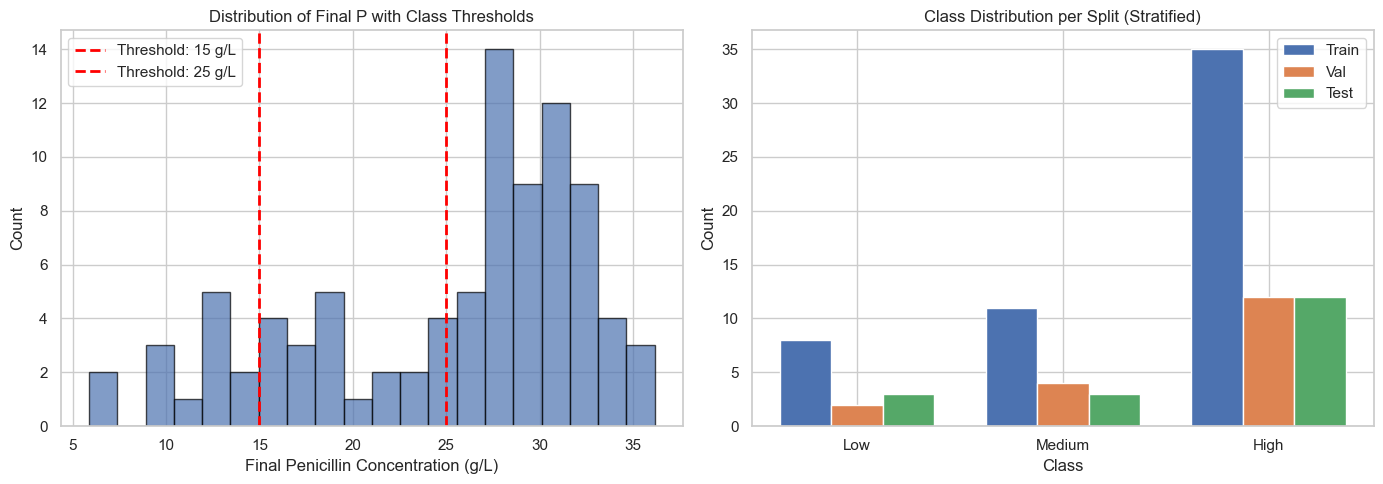


Detailed class distribution per split:
  Train: {'Low': 8, 'Medium': 11, 'High': 35} ({'Low': '15%', 'Medium': '20%', 'High': '65%'})
  Val: {'Low': 2, 'Medium': 4, 'High': 12} ({'Low': '11%', 'Medium': '22%', 'High': '67%'})
  Test: {'Low': 3, 'Medium': 3, 'High': 12} ({'Low': '17%', 'Medium': '17%', 'High': '67%'})


In [4]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of P values with class thresholds
ax = axes[0]
ax.hist(p_df["P"], bins=20, edgecolor='black', alpha=0.7)
for thresh in CLASS_THRESHOLDS:
    ax.axvline(thresh, color='red', linestyle='--', linewidth=2, label=f'Threshold: {thresh} g/L')
ax.set_xlabel("Final Penicillin Concentration (g/L)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Final P with Class Thresholds")
ax.legend()

# Bar chart of class counts per split
ax = axes[1]
splits = {
    "Train": train_ids,
    "Val": val_ids,
    "Test": test_ids,
}
class_counts = {}
for split_name, ids in splits.items():
    class_counts[split_name] = [
        sum(class_labels[bid] == c for bid in ids)
        for c in range(3)
    ]

x = np.arange(len(CLASS_NAMES))
width = 0.25
for i, (split_name, counts) in enumerate(class_counts.items()):
    ax.bar(x + i * width, counts, width, label=split_name)

ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class Distribution per Split (Stratified)")
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/rf_classification_class_dist.png", dpi=150, bbox_inches='tight')
plt.show()

# Print detailed split info
print("\nDetailed class distribution per split:")
for split_name, counts in class_counts.items():
    total = sum(counts)
    pcts = [c/total*100 for c in counts]
    print(f"  {split_name}: {dict(zip(CLASS_NAMES, counts))} ({dict(zip(CLASS_NAMES, [f'{p:.0f}%' for p in pcts]))})")

## 4. Patch Visualization

In [5]:
def compute_patch_indices(n_timesteps: int, n_patches: int) -> list[tuple[int, int]]:
    """Compute start/end indices for equal-sized patches.
    
    Args:
        n_timesteps: Total number of timesteps.
        n_patches: Number of patches to create.
        
    Returns:
        List of (start_idx, end_idx) tuples for each patch.
    """
    patch_size = n_timesteps // n_patches
    indices = []
    for i in range(n_patches):
        start = i * patch_size
        end = (i + 1) * patch_size if i < n_patches - 1 else n_timesteps
        indices.append((start, end))
    return indices


# Example batch for visualization
example_batch_id = 1
example_df = batches[example_batch_id]
early_window = extract_early_window(example_df, WINDOW_FRACTION)

# Compute patch indices
patch_indices = compute_patch_indices(len(early_window), N_PATCHES)

print(f"Example batch {example_batch_id}:")
print(f"  Total timesteps: {len(example_df)}")
print(f"  Early window timesteps: {len(early_window)}")
print(f"  Patch indices: {patch_indices}")
print(f"  Time range: {early_window['time'].min():.1f} - {early_window['time'].max():.1f} h")

Example batch 1:
  Total timesteps: 1130
  Early window timesteps: 1017
  Patch indices: [(0, 127), (127, 254), (254, 381), (381, 508), (508, 635), (635, 762), (762, 889), (889, 1017)]
  Time range: 0.2 - 203.4 h


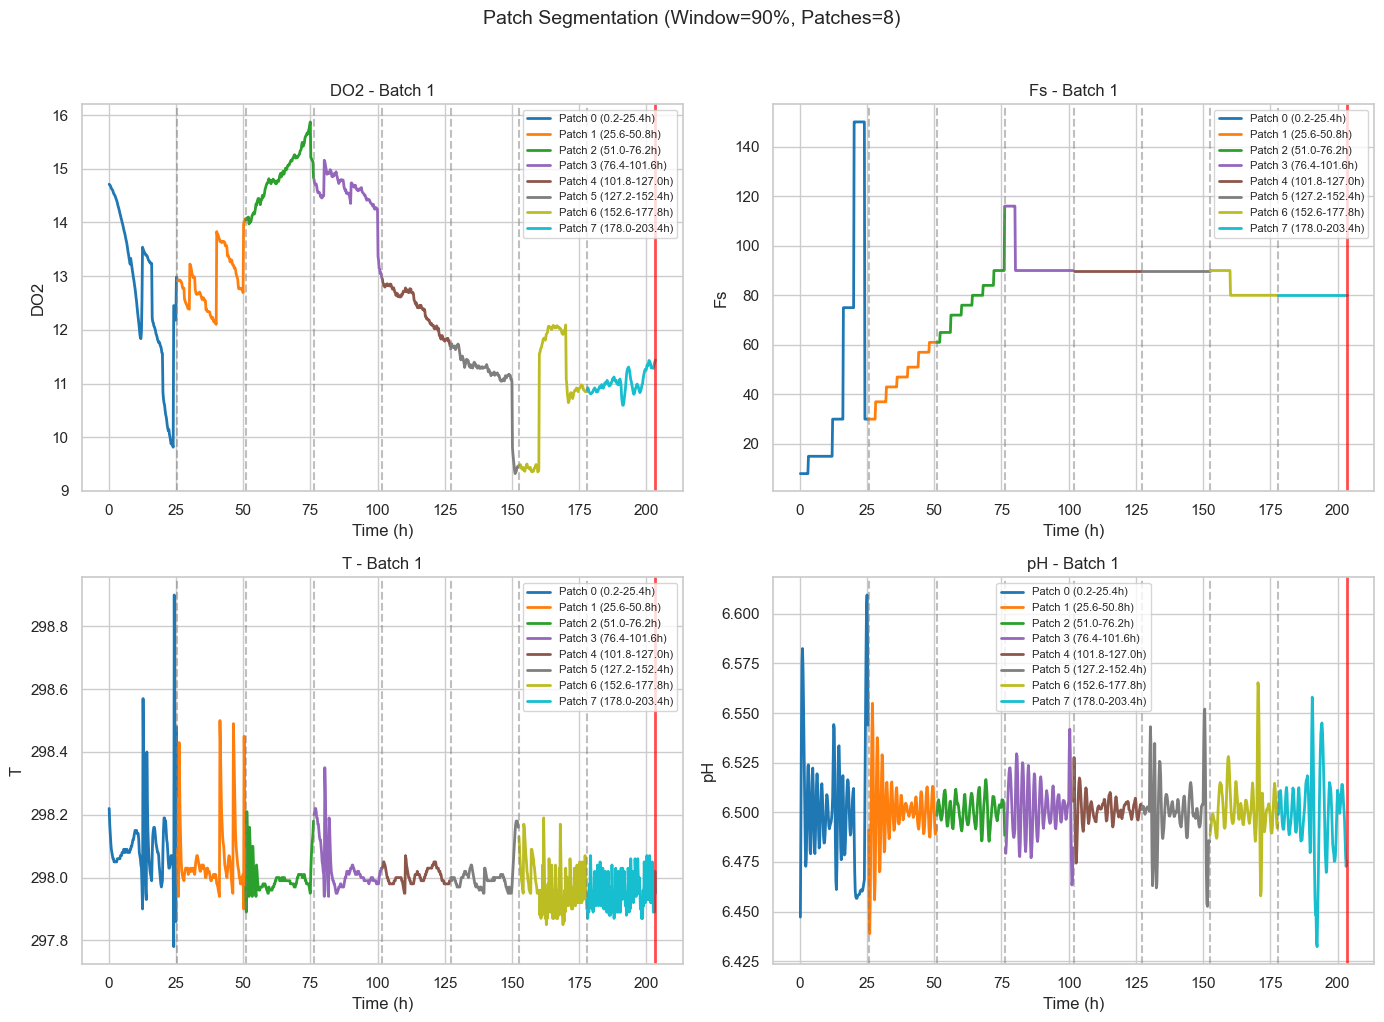

Saved to outputs/figures/rf_classification_patch_viz.png


In [6]:
# Plot example batch with patch segmentation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select features to visualize
viz_features = ["DO2", "Fs", "T", "pH"]
colors = plt.cm.tab10(np.linspace(0, 1, N_PATCHES))

for ax, feat in zip(axes.flat, viz_features):
    time = early_window["time"].values
    values = early_window[feat].values
    
    # Plot each patch with different color
    for i, (start, end) in enumerate(patch_indices):
        patch_time = time[start:end]
        patch_values = values[start:end]
        ax.plot(patch_time, patch_values, color=colors[i], linewidth=2, 
                label=f'Patch {i} ({time[start]:.1f}-{time[end-1]:.1f}h)')
        
        # Mark patch boundaries
        if i > 0:
            ax.axvline(time[start], color='gray', linestyle='--', alpha=0.5)
    
    # Mark early window boundary
    max_time = example_df["time"].max()
    window_end = max_time * WINDOW_FRACTION
    ax.axvline(window_end, color='red', linestyle='-', linewidth=2, alpha=0.7)
    
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(feat)
    ax.set_title(f"{feat} - Batch {example_batch_id}")
    ax.legend(fontsize=8, loc='best')

plt.suptitle(f"Patch Segmentation (Window={WINDOW_FRACTION*100:.0f}%, Patches={N_PATCHES})", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/rf_classification_patch_viz.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/rf_classification_patch_viz.png")

## 5. Feature Extraction Functions

In [7]:
def extract_patch_features(
    df: pd.DataFrame,
    features: list[str],
    patch_indices: list[tuple[int, int]],
) -> dict:
    """Extract statistical features from each patch.
    
    For each feature and patch, computes: mean, std, min, max, slope.
    
    Args:
        df: Early window DataFrame.
        features: List of feature column names.
        patch_indices: List of (start, end) index tuples.
        
    Returns:
        Dict of feature_name -> value.
    """
    result = {}
    time = df["time"].values
    
    for feat in features:
        if feat not in df.columns:
            continue
        
        values = df[feat]
        
        # Interpolate sparse offline features to fill NaNs
        if get_signal_type(feat) == SIGNAL_SPARSE_OFFLINE:
            values = interpolate_sparse_feature(values)
        
        values = values.values
        
        for patch_i, (start, end) in enumerate(patch_indices):
            patch_values = values[start:end]
            patch_time = time[start:end]
            
            # Basic statistics
            result[f"{feat}_mean_patch{patch_i}"] = np.mean(patch_values)
            result[f"{feat}_std_patch{patch_i}"] = np.std(patch_values)
            result[f"{feat}_min_patch{patch_i}"] = np.min(patch_values)
            result[f"{feat}_max_patch{patch_i}"] = np.max(patch_values)
            
            # Slope
            if len(patch_values) > 1 and (patch_time[-1] - patch_time[0]) > 0:
                slope = (patch_values[-1] - patch_values[0]) / (patch_time[-1] - patch_time[0])
            else:
                slope = 0.0
            result[f"{feat}_slope_patch{patch_i}"] = slope
    
    return result


def prepare_classification_data(
    batches: dict[int, pd.DataFrame],
    batch_ids: list[int],
    features: list[str] = INPUT_FEATURES_EXPANDED,
    window_fraction: float = WINDOW_FRACTION,
    n_patches: int = N_PATCHES,
    target_time_fraction: float = TARGET_TIME_FRACTION,
    thresholds: list = CLASS_THRESHOLDS,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Prepare feature matrix and class labels for classification.
    
    Args:
        batches: Dict of batch DataFrames.
        batch_ids: List of batch IDs to include.
        features: Input feature columns.
        window_fraction: Fraction of batch for early window.
        n_patches: Number of patches to segment window into.
        target_time_fraction: Time fraction for target P value.
        thresholds: Class thresholds.
        
    Returns:
        Tuple of (X, y, feature_names).
    """
    X_rows = []
    y_values = []
    feature_names = None
    
    for batch_id in batch_ids:
        df = batches[batch_id]
        early = extract_early_window(df, window_fraction)
        
        # Compute patch indices
        patch_indices = compute_patch_indices(len(early), n_patches)
        
        # Extract features
        feats = extract_patch_features(early, features, patch_indices)
        X_rows.append(feats)
        
        # Get target class
        p_value = get_target_p(df, target_time_fraction)
        y_values.append(assign_class(p_value, thresholds))
        
        if feature_names is None:
            feature_names = list(feats.keys())
    
    X_df = pd.DataFrame(X_rows)
    return X_df.values, np.array(y_values), feature_names


# Test feature extraction
X_test, y_test, feat_names = prepare_classification_data(batches, [1, 2, 3])
print(f"Feature extraction test:")
print(f"  X shape: {X_test.shape}")
print(f"  y shape: {y_test.shape}")
print(f"  Number of features: {len(feat_names)}")
print(f"  Expected: {len(INPUT_FEATURES_EXPANDED)} features x 5 stats x {N_PATCHES} patches = {len(INPUT_FEATURES_EXPANDED) * 5 * N_PATCHES}")
print(f"\nSample feature names:")
for name in feat_names[:10]:
    print(f"  {name}")

Feature extraction test:
  X shape: (3, 1000)
  y shape: (3,)
  Number of features: 1000
  Expected: 25 features x 5 stats x 8 patches = 1000

Sample feature names:
  Fg_mean_patch0
  Fg_std_patch0
  Fg_min_patch0
  Fg_max_patch0
  Fg_slope_patch0
  Fg_mean_patch1
  Fg_std_patch1
  Fg_min_patch1
  Fg_max_patch1
  Fg_slope_patch1


## 6. Prepare Classification Data

In [8]:
# Prepare data for each split
X_train, y_train, feature_names = prepare_classification_data(batches, train_ids)
X_val, y_val, _ = prepare_classification_data(batches, val_ids)
X_test, y_test, _ = prepare_classification_data(batches, test_ids)

print("Data shapes:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val: X={X_val.shape}, y={y_val.shape}")
print(f"  Test: X={X_test.shape}, y={y_test.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nClass distribution (stratified):")
for split_name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = [np.sum(y == c) for c in range(3)]
    total = len(y)
    pcts = [c/total*100 for c in counts]
    print(f"  {split_name}: {dict(zip(CLASS_NAMES, counts))} - {dict(zip(CLASS_NAMES, [f'{p:.0f}%' for p in pcts]))}")

Data shapes:
  Train: X=(54, 1000), y=(54,)
  Val: X=(18, 1000), y=(18,)
  Test: X=(18, 1000), y=(18,)

Class distribution (stratified):
  Train: {'Low': np.int64(8), 'Medium': np.int64(11), 'High': np.int64(35)} - {'Low': '15%', 'Medium': '20%', 'High': '65%'}
  Val: {'Low': np.int64(2), 'Medium': np.int64(4), 'High': np.int64(12)} - {'Low': '11%', 'Medium': '22%', 'High': '67%'}
  Test: {'Low': np.int64(3), 'Medium': np.int64(3), 'High': np.int64(12)} - {'Low': '17%', 'Medium': '17%', 'High': '67%'}


## 7. Hyperparameter Tuning

In [9]:
# GridSearchCV with stratified 5-fold CV
# Using neg_log_loss to penalize overconfident predictions and reduce overfitting
param_grid = {
    "n_estimators": [5, 10, 20],
    "max_depth": [2, 3],              # Limit depth to reduce overfitting
    "min_samples_leaf": [5, 10],      # Increase minimum samples
    "max_features": ["sqrt", 0.3],    # Add feature subsampling
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=cv,
    scoring="neg_log_loss",  # Changed from f1_macro to reduce overfitting
    n_jobs=-1,
    verbose=1,
)

print("Running GridSearchCV with neg_log_loss scoring...")
print("(Log-loss penalizes overconfident wrong predictions, promoting better calibration)")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV log-loss: {-grid_search.best_score_:.3f}")

Running GridSearchCV with neg_log_loss scoring...
(Log-loss penalizes overconfident wrong predictions, promoting better calibration)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 20}
Best CV log-loss: 0.498


In [10]:
# Display top 10 parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values("rank_test_score").head(10)

display_cols = [
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf", "param_max_features",
    "mean_test_score", "std_test_score", "rank_test_score"
]
print("Top 10 parameter combinations (sorted by log-loss, lower is better):")
cv_display = cv_results_sorted[display_cols].copy()
cv_display["mean_test_score"] = -cv_display["mean_test_score"]  # Convert to positive log-loss
cv_display.columns = ["n_estimators", "max_depth", "min_samples_leaf", "max_features", 
                      "log_loss", "std", "rank"]
print(cv_display.to_string(index=False))

Top 10 parameter combinations (sorted by log-loss, lower is better):
 n_estimators  max_depth  min_samples_leaf max_features  log_loss      std  rank
           20          3                 5         sqrt  0.497800 0.119489     1
           20          2                 5         sqrt  0.500082 0.118875     2
           10          3                 5         sqrt  0.509900 0.086013     3
           10          2                 5         sqrt  0.514367 0.087187     4
            5          3                 5         sqrt  0.575948 0.136622     5
            5          2                 5         sqrt  0.579730 0.135159     6
           20          3                10         sqrt  0.643042 0.142529     7
           20          2                10         sqrt  0.643042 0.142529     8
            5          2                10         sqrt  0.662485 0.139130     9
            5          3                10         sqrt  0.662485 0.139130     9


## 8. Evaluation

In [11]:
# Train final model with best parameters
best_model = grid_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

print("Classification Results:")
print("=" * 60)

Classification Results:


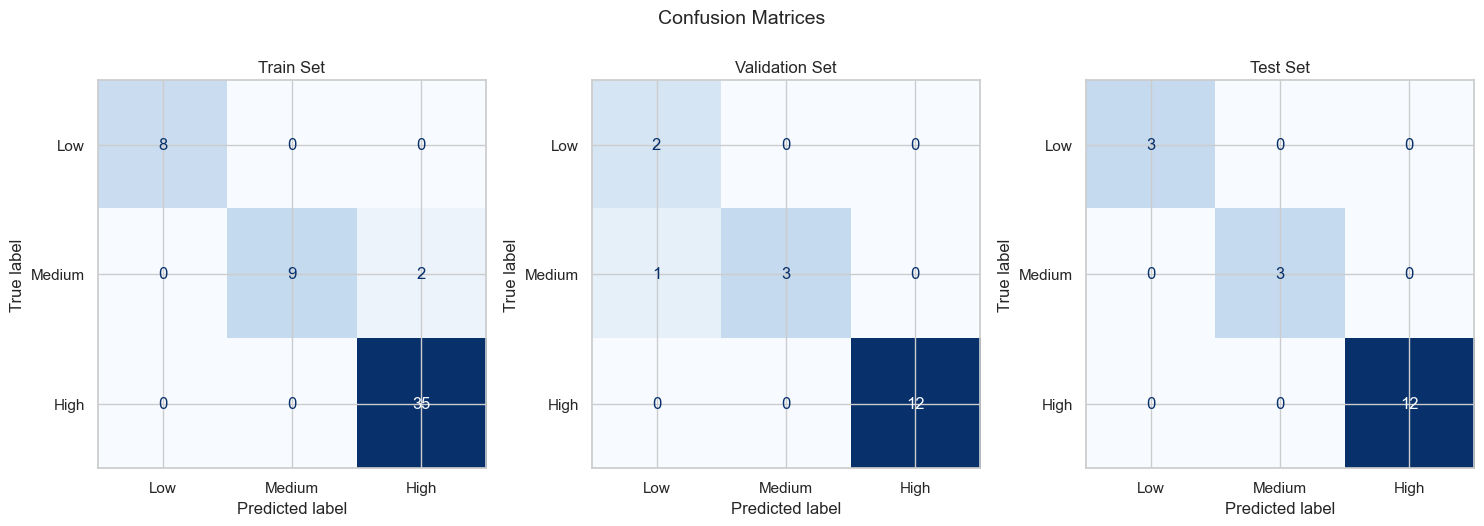

Saved to outputs/figures/rf_classification_confusion.png


In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits_data = [
    ("Train", y_train, y_train_pred),
    ("Validation", y_val, y_val_pred),
    ("Test", y_test, y_test_pred),
]

for ax, (name, y_true, y_pred) in zip(axes, splits_data):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} Set")

plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/rf_classification_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/rf_classification_confusion.png")

In [13]:
# Classification reports (with labels parameter to handle missing classes)
print("\n" + "=" * 60)
print("TRAIN SET")
print("=" * 60)
print(classification_report(y_train, y_train_pred, labels=[0, 1, 2], 
                            target_names=CLASS_NAMES, zero_division=0))

print("\n" + "=" * 60)
print("VALIDATION SET")
print("=" * 60)
print(classification_report(y_val, y_val_pred, labels=[0, 1, 2], 
                            target_names=CLASS_NAMES, zero_division=0))

print("\n" + "=" * 60)
print("TEST SET")
print("=" * 60)
print(classification_report(y_test, y_test_pred, labels=[0, 1, 2], 
                            target_names=CLASS_NAMES, zero_division=0))


TRAIN SET
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         8
      Medium       1.00      0.82      0.90        11
        High       0.95      1.00      0.97        35

    accuracy                           0.96        54
   macro avg       0.98      0.94      0.96        54
weighted avg       0.96      0.96      0.96        54


VALIDATION SET
              precision    recall  f1-score   support

         Low       0.67      1.00      0.80         2
      Medium       1.00      0.75      0.86         4
        High       1.00      1.00      1.00        12

    accuracy                           0.94        18
   macro avg       0.89      0.92      0.89        18
weighted avg       0.96      0.94      0.95        18


TEST SET
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         3
      Medium       1.00      1.00      1.00         3
        High       1.00      1.00     

In [14]:
# Feature importance (Gini-based from training)
print("\nComputing feature importance from trained model...")

# Get Gini importances from the model
gini_importance = best_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": gini_importance,
}).sort_values("importance", ascending=False)

# Filter to non-zero importances
nonzero_importance = importance_df[importance_df["importance"] > 0]
print(f"\nFeatures with non-zero importance: {len(nonzero_importance)} / {len(feature_names)}")

print("\nTop 20 features by Gini importance:")
print(importance_df.head(20).to_string(index=False))


Computing feature importance from trained model...

Features with non-zero importance: 50 / 1000

Top 20 features by Gini importance:
                 feature  importance
         OUR_mean_patch7    0.094239
  NH3_offline_max_patch7    0.068486
NH3_offline_slope_patch7    0.065911
  PAA_offline_max_patch6    0.048168
  NH3_offline_min_patch6    0.043257
          Fa_mean_patch7    0.041848
           S_mean_patch7    0.040087
          OUR_min_patch7    0.039259
            T_std_patch6    0.035435
          S_slope_patch7    0.033473
    X_offline_std_patch6    0.032962
NH3_offline_slope_patch6    0.032710
          CER_min_patch7    0.032664
          O2_mean_patch7    0.030830
            V_std_patch7    0.028912
           O2_max_patch7    0.027683
           Fb_max_patch6    0.021741
    X_offline_std_patch7    0.021099
            S_min_patch7    0.019134
           S_mean_patch5    0.015903


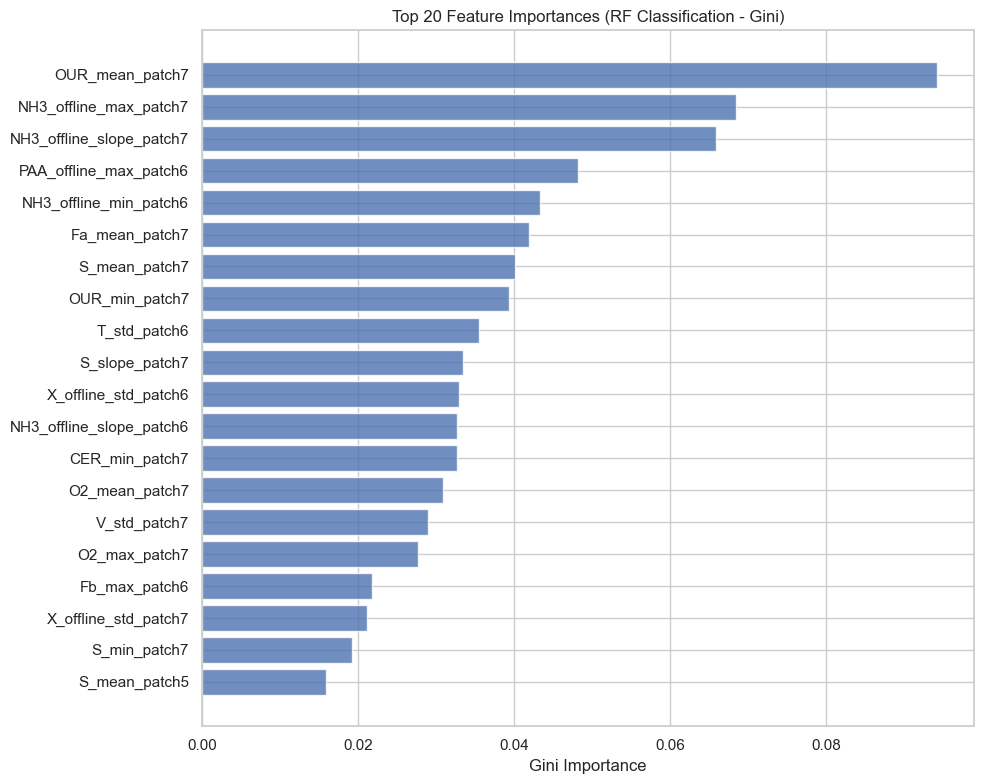

In [15]:
# Plot top 20 feature importances
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)

ax.barh(y_pos, top_features["importance"], align='center', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features["feature"])
ax.invert_yaxis()
ax.set_xlabel('Gini Importance')
ax.set_title(f'Top {top_n} Feature Importances (RF Classification - Gini)')

plt.tight_layout()
plt.savefig('../outputs/figures/rf_classification_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# RF Summary — store results for benchmark comparison

print("\n" + "=" * 60)
print("RF SUMMARY")
print("=" * 60)
print(f"\nBest hyperparameters: {grid_search.best_params_}")

# Compute probabilities for log-loss
y_train_proba = best_model.predict_proba(X_train_scaled)
y_val_proba = best_model.predict_proba(X_val_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

# Store results in dict for benchmark comparison
rf_results = {}
for name, y_true, y_pred, y_proba in [
    ("Train", y_train, y_train_pred, y_train_proba),
    ("Val", y_val, y_val_pred, y_val_proba),
    ("Test", y_test, y_test_pred, y_test_proba),
]:
    rf_results[name] = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average='macro', labels=[0, 1, 2], zero_division=0),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1, 2]),
    }

rf_results["best_params"] = grid_search.best_params_
rf_results["cv_log_loss"] = -grid_search.best_score_
rf_results["importance_df"] = importance_df.copy()

print(f"\nPerformance metrics:")
print(f"{'Split':<12} {'Accuracy':<12} {'F1 (macro)':<12} {'Log-Loss'}")
print("-" * 48)
for split in ["Train", "Val", "Test"]:
    r = rf_results[split]
    print(f"{split:<12} {r['accuracy']:<12.3f} {r['f1_macro']:<12.3f} {r['log_loss']:.3f}")

train_f1 = rf_results["Train"]["f1_macro"]
test_f1 = rf_results["Test"]["f1_macro"]
f1_gap = train_f1 - test_f1
print(f"\nOverfitting Analysis:")
print(f"  Train-Test F1 gap: {f1_gap:.3f}")
print(f"  CV log-loss: {rf_results['cv_log_loss']:.3f}")


RF SUMMARY

Best hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 20}

Performance metrics:
Split        Accuracy     F1 (macro)   Log-Loss
------------------------------------------------
Train        0.963        0.957        0.232
Val          0.944        0.886        0.257
Test         1.000        1.000        0.273

Overfitting Analysis:
  Train-Test F1 gap: -0.043
  CV log-loss: 0.498


## 8. XGBoost Classifier

In [17]:
# XGBoost GridSearchCV with same CV strategy as RF
xgb_param_grid = {
    "n_estimators": [5, 10, 20, 50, 100],
    "max_depth": [2, 3],
    "learning_rate": [0.01, 0.1, 1.0],
    "subsample": [0.8],
    "colsample_bytree": [0.3, 0.5],
    "reg_alpha": [0.1, 1.0, 10.0],
    "reg_lambda": [0.1, 0.5, 1.0],
    "min_child_weight": [1, 2, 3],
}

xgb = XGBClassifier(
    objective="multi:softprob",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_grid_search = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=cv,
    scoring="neg_log_loss",
    n_jobs=-1,
    verbose=1,
)

n_candidates = np.prod([len(v) for v in xgb_param_grid.values()])
print(f"Running XGBoost GridSearchCV ({n_candidates} candidates)...")
xgb_grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {xgb_grid_search.best_params_}")
print(f"Best CV log-loss: {-xgb_grid_search.best_score_:.3f}")

Running XGBoost GridSearchCV (1620 candidates)...
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits

Best parameters: {'colsample_bytree': 0.5, 'learning_rate': 1.0, 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 10, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'subsample': 0.8}
Best CV log-loss: 0.340


In [18]:
# Top 10 XGBoost CV results
xgb_cv_results = pd.DataFrame(xgb_grid_search.cv_results_)
xgb_cv_sorted = xgb_cv_results.sort_values("rank_test_score").head(10)

display_cols = [
    "param_n_estimators", "param_max_depth", "param_learning_rate",
    "param_colsample_bytree", "param_reg_alpha", "param_reg_lambda",
    "param_min_child_weight", "mean_test_score", "std_test_score", "rank_test_score",
]
print("Top 10 XGBoost parameter combinations (sorted by log-loss):")
xgb_display = xgb_cv_sorted[display_cols].copy()
xgb_display["mean_test_score"] = -xgb_display["mean_test_score"]
xgb_display.columns = [
    "n_est", "depth", "lr", "colsample", "alpha", "lambda",
    "min_cw", "log_loss", "std", "rank",
]
print(xgb_display.to_string(index=False))

Top 10 XGBoost parameter combinations (sorted by log-loss):
 n_est  depth  lr  colsample  alpha  lambda  min_cw  log_loss      std  rank
    10      3 1.0        0.5    0.1     0.5       2  0.340458 0.133404     1
    10      2 1.0        0.5    0.1     0.5       2  0.340458 0.133404     1
    10      2 1.0        0.5    0.1     0.1       2  0.343917 0.177154     3
    10      3 1.0        0.5    0.1     0.1       2  0.343917 0.177154     3
    50      2 1.0        0.5    0.1     1.0       2  0.345204 0.182784     5
    50      3 1.0        0.5    0.1     1.0       2  0.345204 0.182784     5
     5      2 1.0        0.5    0.1     1.0       2  0.345285 0.161974     7
     5      3 1.0        0.5    0.1     1.0       2  0.345285 0.161974     7
    50      3 1.0        0.5    0.1     0.5       2  0.347412 0.126492     9
    50      2 1.0        0.5    0.1     0.5       2  0.347412 0.126492     9


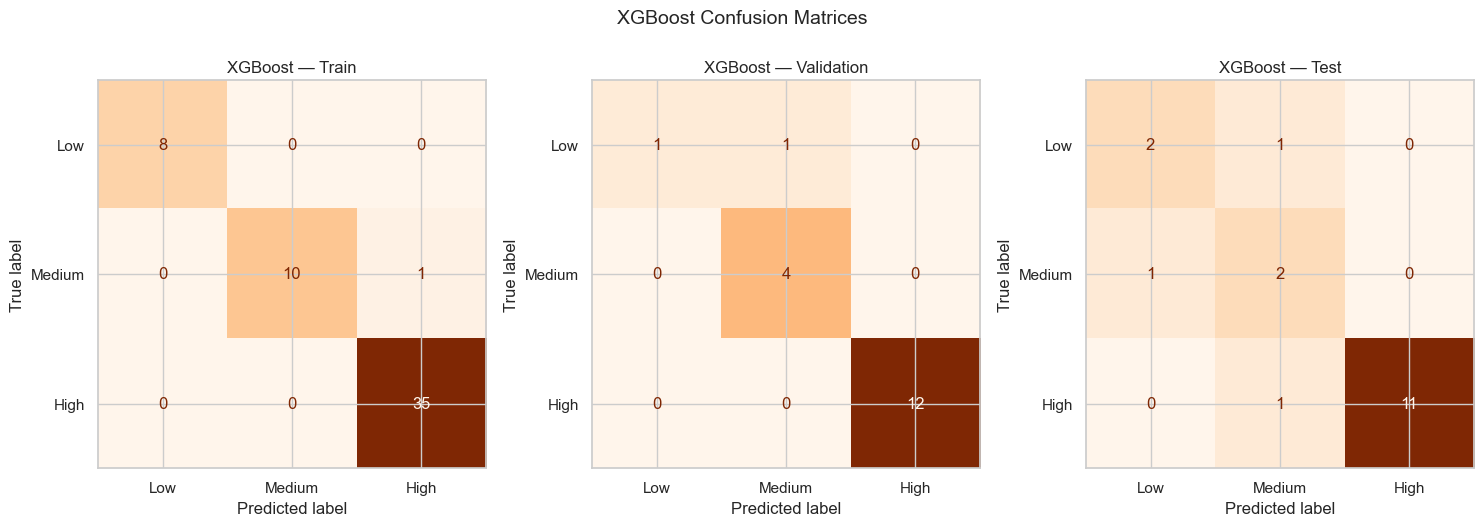


XGBoost TRAIN SET
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         8
      Medium       1.00      0.91      0.95        11
        High       0.97      1.00      0.99        35

    accuracy                           0.98        54
   macro avg       0.99      0.97      0.98        54
weighted avg       0.98      0.98      0.98        54


XGBoost VALIDATION SET
              precision    recall  f1-score   support

         Low       1.00      0.50      0.67         2
      Medium       0.80      1.00      0.89         4
        High       1.00      1.00      1.00        12

    accuracy                           0.94        18
   macro avg       0.93      0.83      0.85        18
weighted avg       0.96      0.94      0.94        18


XGBoost TEST SET
              precision    recall  f1-score   support

         Low       0.67      0.67      0.67         3
      Medium       0.50      0.67      0.57         3
        High  

In [19]:
# XGBoost evaluation — confusion matrices and classification reports
xgb_best = xgb_grid_search.best_estimator_

xgb_train_pred = xgb_best.predict(X_train_scaled)
xgb_val_pred = xgb_best.predict(X_val_scaled)
xgb_test_pred = xgb_best.predict(X_test_scaled)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_true, y_pred) in zip(axes, [
    ("Train", y_train, xgb_train_pred),
    ("Validation", y_val, xgb_val_pred),
    ("Test", y_test, xgb_test_pred),
]):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Oranges", colorbar=False)
    ax.set_title(f"XGBoost — {name}")

plt.suptitle("XGBoost Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Classification reports
for name, y_true, y_pred in [
    ("TRAIN", y_train, xgb_train_pred),
    ("VALIDATION", y_val, xgb_val_pred),
    ("TEST", y_test, xgb_test_pred),
]:
    print(f"\n{'=' * 60}\nXGBoost {name} SET\n{'=' * 60}")
    print(classification_report(y_true, y_pred, labels=[0, 1, 2],
                                target_names=CLASS_NAMES, zero_division=0))

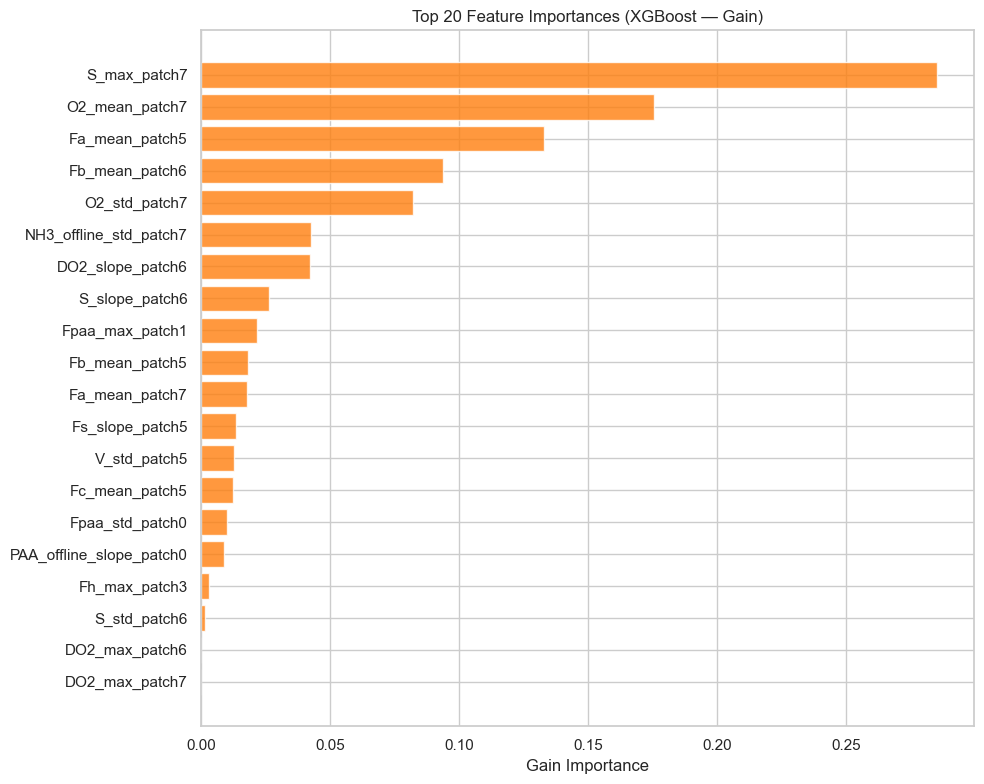

XGBoost results stored.
  Test accuracy: 0.833
  Test F1 macro: 0.732
  Test log-loss: 0.316


In [20]:
# XGBoost feature importance (gain) and results storage
xgb_importance = xgb_best.feature_importances_
xgb_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importance,
}).sort_values("importance", ascending=False)

# Plot top 20
top_n = 20
top_xgb = xgb_importance_df.head(top_n)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(np.arange(top_n), top_xgb["importance"], align='center', alpha=0.8, color='tab:orange')
ax.set_yticks(np.arange(top_n))
ax.set_yticklabels(top_xgb["feature"])
ax.invert_yaxis()
ax.set_xlabel("Gain Importance")
ax.set_title(f"Top {top_n} Feature Importances (XGBoost — Gain)")
plt.tight_layout()
plt.show()

# Store results
xgb_train_proba = xgb_best.predict_proba(X_train_scaled)
xgb_val_proba = xgb_best.predict_proba(X_val_scaled)
xgb_test_proba = xgb_best.predict_proba(X_test_scaled)

xgb_results = {}
for name, y_true, y_pred, y_proba in [
    ("Train", y_train, xgb_train_pred, xgb_train_proba),
    ("Val", y_val, xgb_val_pred, xgb_val_proba),
    ("Test", y_test, xgb_test_pred, xgb_test_proba),
]:
    xgb_results[name] = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average='macro', labels=[0, 1, 2], zero_division=0),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1, 2]),
    }

xgb_results["best_params"] = xgb_grid_search.best_params_
xgb_results["cv_log_loss"] = -xgb_grid_search.best_score_
xgb_results["importance_df"] = xgb_importance_df.copy()

print("XGBoost results stored.")
print(f"  Test accuracy: {xgb_results['Test']['accuracy']:.3f}")
print(f"  Test F1 macro: {xgb_results['Test']['f1_macro']:.3f}")
print(f"  Test log-loss: {xgb_results['Test']['log_loss']:.3f}")

## 9. LightGBM Classifier

In [21]:
# LightGBM GridSearchCV with same CV strategy
lgbm_param_grid = {
    "n_estimators": [20, 50, 100],
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.3, 0.5],
    "reg_alpha": [0.1, 1.0],
    "reg_lambda": [1.0, 5.0],
    "min_child_weight": [3, 5],
    "num_leaves": [4, 8],
    "min_child_samples": [5, 10],
}

lgbm = LGBMClassifier(
    objective="multiclass",
    importance_type="gain",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgbm_grid_search = GridSearchCV(
    lgbm,
    lgbm_param_grid,
    cv=cv,
    scoring="neg_log_loss",
    n_jobs=-1,
    verbose=1,
)

n_candidates = np.prod([len(v) for v in lgbm_param_grid.values()])
print(f"Running LightGBM GridSearchCV ({n_candidates} candidates)...")
lgbm_grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {lgbm_grid_search.best_params_}")
print(f"Best CV log-loss: {-lgbm_grid_search.best_score_:.3f}")

Running LightGBM GridSearchCV (768 candidates)...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast


Best parameters: {'colsample_bytree': 0.3, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_samples': 5, 'min_child_weight': 3, 'n_estimators': 100, 'num_leaves': 4, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV log-loss: 0.412


In [22]:
# Top 10 LightGBM CV results
lgbm_cv_results = pd.DataFrame(lgbm_grid_search.cv_results_)
lgbm_cv_sorted = lgbm_cv_results.sort_values("rank_test_score").head(10)

display_cols = [
    "param_n_estimators", "param_max_depth", "param_learning_rate",
    "param_num_leaves", "param_min_child_samples",
    "param_colsample_bytree", "param_reg_alpha", "param_reg_lambda",
    "mean_test_score", "std_test_score", "rank_test_score",
]
print("Top 10 LightGBM parameter combinations (sorted by log-loss):")
lgbm_display = lgbm_cv_sorted[display_cols].copy()
lgbm_display["mean_test_score"] = -lgbm_display["mean_test_score"]
lgbm_display.columns = [
    "n_est", "depth", "lr", "leaves", "min_cs",
    "colsample", "alpha", "lambda", "log_loss", "std", "rank",
]
print(lgbm_display.to_string(index=False))

Top 10 LightGBM parameter combinations (sorted by log-loss):
 n_est  depth   lr  leaves  min_cs  colsample  alpha  lambda  log_loss      std  rank
   100      2 0.05       8       5        0.3    0.1     1.0  0.412151 0.150694     1
   100      3 0.05       4       5        0.3    0.1     1.0  0.412151 0.150694     1
   100      3 0.05       8       5        0.3    0.1     1.0  0.412151 0.150694     1
   100      2 0.05       4       5        0.3    0.1     1.0  0.412151 0.150694     1
   100      3 0.10       8       5        0.3    0.1     1.0  0.422398 0.148652     5
    50      3 0.10       8       5        0.3    0.1     1.0  0.422398 0.148652     5
    50      2 0.10       8       5        0.3    0.1     1.0  0.422398 0.148652     5
   100      2 0.10       4       5        0.3    0.1     1.0  0.422398 0.148652     5
    50      3 0.10       4       5        0.3    0.1     1.0  0.422398 0.148652     5
    50      2 0.10       4       5        0.3    0.1     1.0  0.422398 0.148652

/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


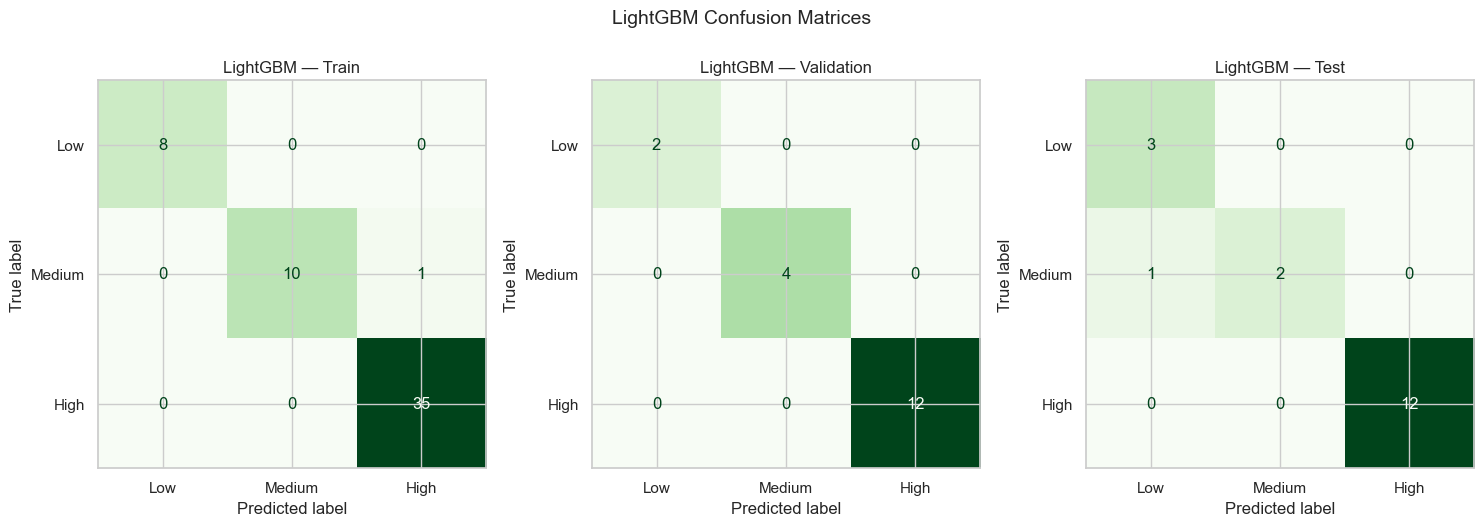


LightGBM TRAIN SET
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         8
      Medium       1.00      0.91      0.95        11
        High       0.97      1.00      0.99        35

    accuracy                           0.98        54
   macro avg       0.99      0.97      0.98        54
weighted avg       0.98      0.98      0.98        54


LightGBM VALIDATION SET
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         4
        High       1.00      1.00      1.00        12

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


LightGBM TEST SET
              precision    recall  f1-score   support

         Low       0.75      1.00      0.86         3
      Medium       1.00      0.67      0.80         3
        Hig

In [23]:
# LightGBM evaluation — confusion matrices and classification reports
lgbm_best = lgbm_grid_search.best_estimator_

lgbm_train_pred = lgbm_best.predict(X_train_scaled)
lgbm_val_pred = lgbm_best.predict(X_val_scaled)
lgbm_test_pred = lgbm_best.predict(X_test_scaled)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_true, y_pred) in zip(axes, [
    ("Train", y_train, lgbm_train_pred),
    ("Validation", y_val, lgbm_val_pred),
    ("Test", y_test, lgbm_test_pred),
]):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(f"LightGBM — {name}")

plt.suptitle("LightGBM Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Classification reports
for name, y_true, y_pred in [
    ("TRAIN", y_train, lgbm_train_pred),
    ("VALIDATION", y_val, lgbm_val_pred),
    ("TEST", y_test, lgbm_test_pred),
]:
    print(f"\n{'=' * 60}\nLightGBM {name} SET\n{'=' * 60}")
    print(classification_report(y_true, y_pred, labels=[0, 1, 2],
                                target_names=CLASS_NAMES, zero_division=0))

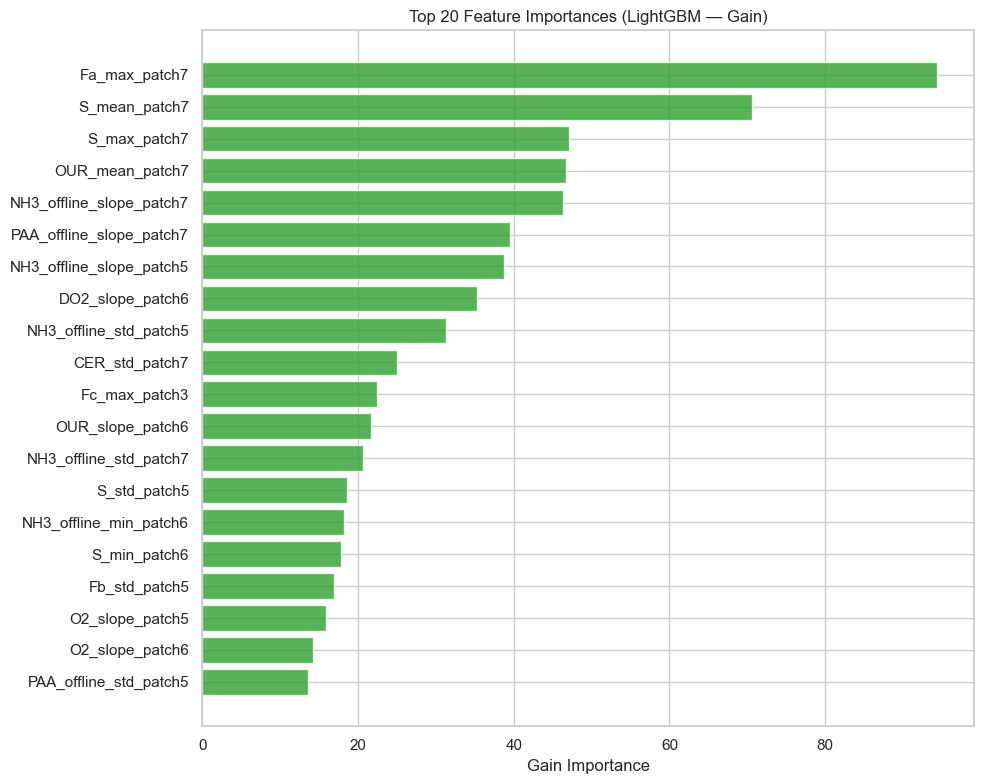

LightGBM results stored.
  Test accuracy: 0.944
  Test F1 macro: 0.886
  Test log-loss: 0.316


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [24]:
# LightGBM feature importance (gain) and results storage
lgbm_importance = lgbm_best.feature_importances_
lgbm_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_importance,
}).sort_values("importance", ascending=False)

# Plot top 20
top_n = 20
top_lgbm = lgbm_importance_df.head(top_n)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(np.arange(top_n), top_lgbm["importance"], align='center', alpha=0.8, color='tab:green')
ax.set_yticks(np.arange(top_n))
ax.set_yticklabels(top_lgbm["feature"])
ax.invert_yaxis()
ax.set_xlabel("Gain Importance")
ax.set_title(f"Top {top_n} Feature Importances (LightGBM — Gain)")
plt.tight_layout()
plt.show()

# Store results
lgbm_train_proba = lgbm_best.predict_proba(X_train_scaled)
lgbm_val_proba = lgbm_best.predict_proba(X_val_scaled)
lgbm_test_proba = lgbm_best.predict_proba(X_test_scaled)

lgbm_results = {}
for name, y_true, y_pred, y_proba in [
    ("Train", y_train, lgbm_train_pred, lgbm_train_proba),
    ("Val", y_val, lgbm_val_pred, lgbm_val_proba),
    ("Test", y_test, lgbm_test_pred, lgbm_test_proba),
]:
    lgbm_results[name] = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average='macro', labels=[0, 1, 2], zero_division=0),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1, 2]),
    }

lgbm_results["best_params"] = lgbm_grid_search.best_params_
lgbm_results["cv_log_loss"] = -lgbm_grid_search.best_score_
lgbm_results["importance_df"] = lgbm_importance_df.copy()

print("LightGBM results stored.")
print(f"  Test accuracy: {lgbm_results['Test']['accuracy']:.3f}")
print(f"  Test F1 macro: {lgbm_results['Test']['f1_macro']:.3f}")
print(f"  Test log-loss: {lgbm_results['Test']['log_loss']:.3f}")

## 10. Benchmark Comparison

In [25]:
# Benchmark table — all models x all splits x all metrics
all_results = {"RF": rf_results, "XGBoost": xgb_results, "LightGBM": lgbm_results}

rows = []
for model_name, results in all_results.items():
    for split in ["Train", "Val", "Test"]:
        r = results[split]
        rows.append({
            "Model": model_name,
            "Split": split,
            "Accuracy": r["accuracy"],
            "F1-macro": r["f1_macro"],
            "Log-Loss": r["log_loss"],
        })

benchmark_df = pd.DataFrame(rows)

print("=" * 70)
print("BENCHMARK RESULTS")
print("=" * 70)
print(benchmark_df.to_string(index=False))

# Test-set summary
print(f"\n{'=' * 70}")
print("TEST SET SUMMARY")
print("=" * 70)
test_df = benchmark_df[benchmark_df["Split"] == "Test"].copy()
print(test_df[["Model", "Accuracy", "F1-macro", "Log-Loss"]].to_string(index=False))

best_model_name = test_df.loc[test_df["Log-Loss"].idxmin(), "Model"]
best_ll = test_df["Log-Loss"].min()
print(f"\nBest model by test log-loss: {best_model_name} ({best_ll:.3f})")

BENCHMARK RESULTS
   Model Split  Accuracy  F1-macro  Log-Loss
      RF Train  0.962963  0.957407  0.231694
      RF   Val  0.944444  0.885714  0.257430
      RF  Test  1.000000  1.000000  0.273497
 XGBoost Train  0.981481  0.979432  0.078745
 XGBoost   Val  0.944444  0.851852  0.189551
 XGBoost  Test  0.833333  0.731539  0.315638
LightGBM Train  0.981481  0.979432  0.135354
LightGBM   Val  1.000000  1.000000  0.229089
LightGBM  Test  0.944444  0.885714  0.316493

TEST SET SUMMARY
   Model  Accuracy  F1-macro  Log-Loss
      RF  1.000000  1.000000  0.273497
 XGBoost  0.833333  0.731539  0.315638
LightGBM  0.944444  0.885714  0.316493

Best model by test log-loss: RF (0.273)


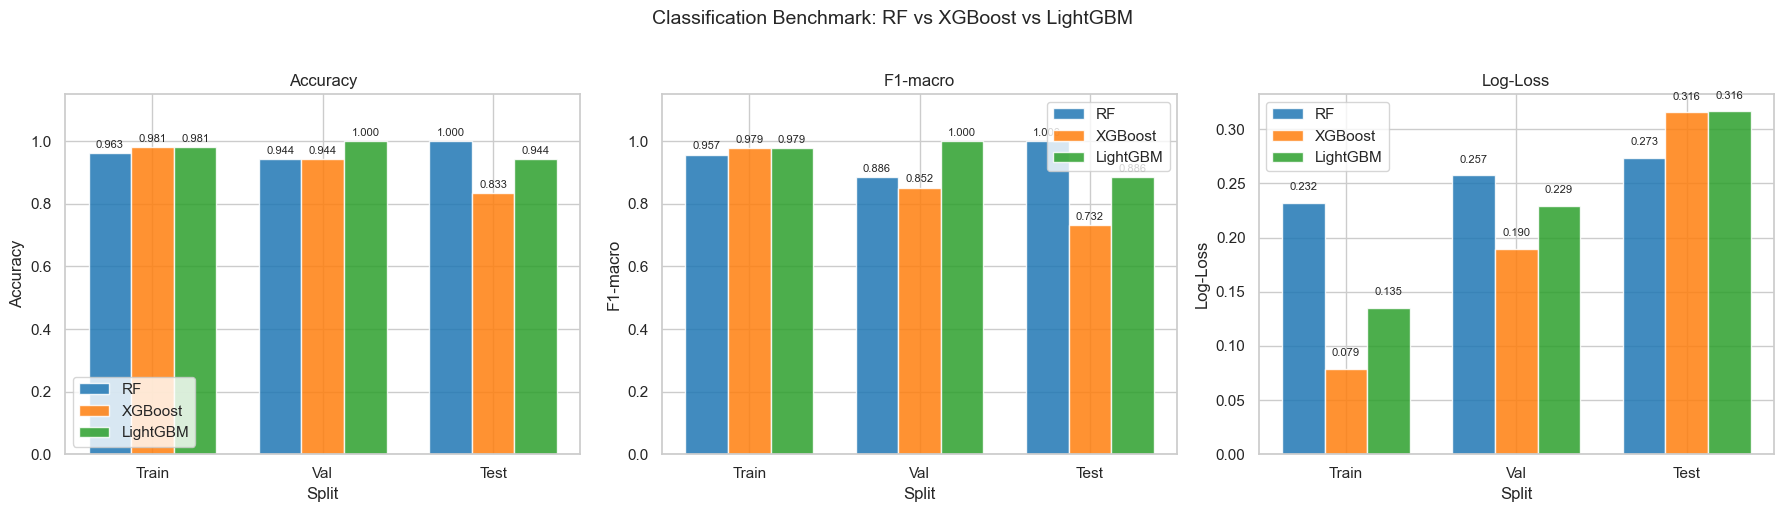

Saved to outputs/figures/classification_benchmark.png


In [26]:
# Benchmark bar chart — 3 models x 3 splits x 3 metrics
metrics = ["Accuracy", "F1-macro", "Log-Loss"]
splits = ["Train", "Val", "Test"]
models = ["RF", "XGBoost", "LightGBM"]
model_colors = {"RF": "tab:blue", "XGBoost": "tab:orange", "LightGBM": "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    x = np.arange(len(splits))
    width = 0.25
    for i, model in enumerate(models):
        values = [
            benchmark_df[(benchmark_df["Model"] == model) & (benchmark_df["Split"] == s)][metric].values[0]
            for s in splits
        ]
        bars = ax.bar(x + i * width, values, width, label=model, color=model_colors[model], alpha=0.85)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha='center', va='bottom', fontsize=8)

    ax.set_xlabel("Split")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(x + width)
    ax.set_xticklabels(splits)
    ax.legend()
    if metric != "Log-Loss":
        ax.set_ylim(0, 1.15)

plt.suptitle("Classification Benchmark: RF vs XGBoost vs LightGBM", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/classification_benchmark.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/classification_benchmark.png")

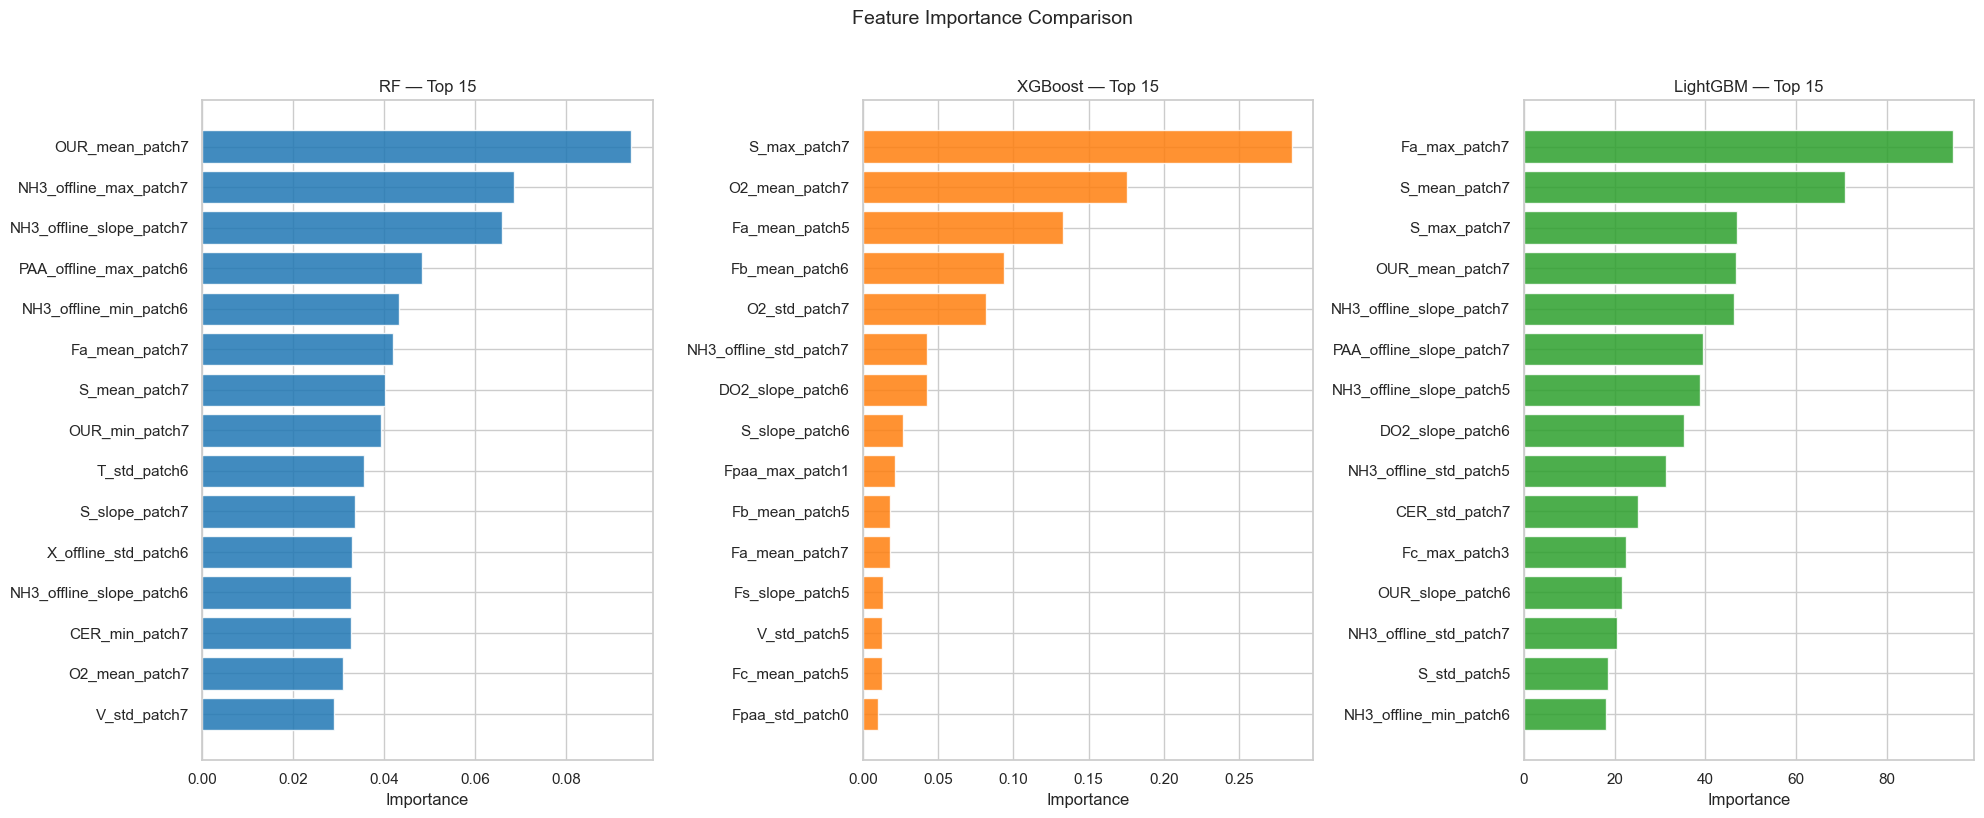


Consensus features (in all three models' top 20): 0


In [27]:
# Feature importance comparison — top 15 per model + consensus features
top_k = 15

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
model_imp = {
    "RF": (rf_results["importance_df"], "tab:blue"),
    "XGBoost": (xgb_results["importance_df"], "tab:orange"),
    "LightGBM": (lgbm_results["importance_df"], "tab:green"),
}

for ax, (model_name, (imp_df, color)) in zip(axes, model_imp.items()):
    top = imp_df.head(top_k)
    ax.barh(np.arange(top_k), top["importance"].values, align='center', alpha=0.85, color=color)
    ax.set_yticks(np.arange(top_k))
    ax.set_yticklabels(top["feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"{model_name} — Top {top_k}")

plt.suptitle("Feature Importance Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Consensus features (in all three models' top 20)
top_20_sets = {
    name: set(imp_df.head(20)["feature"].values)
    for name, (imp_df, _) in model_imp.items()
}
consensus = top_20_sets["RF"] & top_20_sets["XGBoost"] & top_20_sets["LightGBM"]
print(f"\nConsensus features (in all three models' top 20): {len(consensus)}")
for feat in sorted(consensus):
    print(f"  {feat}")

In [28]:
# Overfitting analysis — train-val gap, train-test gap, CV log-loss
print("=" * 70)
print("OVERFITTING ANALYSIS")
print("=" * 70)

print(f"\n{'Model':<12} {'Train-Val Gap':<16} {'Train-Test Gap':<16} {'CV Log-Loss'}")
print(f"{'':12} {'(F1-macro)':<16} {'(F1-macro)':<16}")
print("-" * 60)
for model_name, results in all_results.items():
    tv_gap = results["Train"]["f1_macro"] - results["Val"]["f1_macro"]
    tt_gap = results["Train"]["f1_macro"] - results["Test"]["f1_macro"]
    cv_ll = results["cv_log_loss"]
    print(f"{model_name:<12} {tv_gap:<16.3f} {tt_gap:<16.3f} {cv_ll:.3f}")

print(f"\nBest hyperparameters per model:")
for model_name, results in all_results.items():
    print(f"\n  {model_name}:")
    for k, v in results["best_params"].items():
        print(f"    {k}: {v}")

OVERFITTING ANALYSIS

Model        Train-Val Gap    Train-Test Gap   CV Log-Loss
             (F1-macro)       (F1-macro)      
------------------------------------------------------------
RF           0.072            -0.043           0.498
XGBoost      0.128            0.248            0.340
LightGBM     -0.021           0.094            0.412

Best hyperparameters per model:

  RF:
    max_depth: 3
    max_features: sqrt
    min_samples_leaf: 5
    n_estimators: 20

  XGBoost:
    colsample_bytree: 0.5
    learning_rate: 1.0
    max_depth: 2
    min_child_weight: 2
    n_estimators: 10
    reg_alpha: 0.1
    reg_lambda: 0.5
    subsample: 0.8

  LightGBM:
    colsample_bytree: 0.3
    learning_rate: 0.05
    max_depth: 2
    min_child_samples: 5
    min_child_weight: 3
    n_estimators: 100
    num_leaves: 4
    reg_alpha: 0.1
    reg_lambda: 1.0
    subsample: 0.8
